# Exercícios Práticos com Pandas

Neste notebook, vamos praticar a manipulação de dados usando a biblioteca Pandas com o arquivo `sales.csv`.

In [ ]:
!pip install seaborn

In [2]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-whitegrid')

In [8]:
# Carregando o dataset
df = pd.read_csv('sales.csv')

# Exibindo as primeiras linhas do dataset
print("Primeiras 5 linhas do dataset:")
df.head()

Primeiras 5 linhas do dataset:


,Data,ID_Cliente,Nome_Cliente,ID_Vendedor,Nome_Vendedor,Cidade,Estado,Categoria_Produto,Produto,Quantidade,Preco_Unitario,Desconto,Valor_Total,Custo,Lucro,Metodo_Envio,Frequencia_Compra
0,2023-01-05,C001,João Silva,V001,Ana Oliveira,São Paulo,SP,Eletrônicos,Smartphone,2,1200,0.05,2280.0,1800,480.0,Expresso,3
1,2023-01-10,C002,Maria Santos,V002,Bruno Costa,Rio de Janeiro,RJ,Móveis,Sofá,1,2500,0.10,2250.0,1800,450.0,Padrão,1
2,2023-01-15,C003,Pedro Almeida,V003,Carla Souza,Belo Horizonte,MG,Eletrônicos,Notebook,1,3500,0.00,3500.0,2800,700.0,Expresso,2
3,2023-01-20,C004,Ana Pereira,V004,Daniel Lima,Brasília,DF,Roupas,Camiseta,5,50,0.15,212.5,125,87.5,Econômico,4
4,2023-01-25,C005,Carlos Ferreira,V001,Ana Oliveira,São Paulo,SP,Alimentos,Cesta Básica,2,180,0.00,360.0,280,80.0,Padrão,2


In [4]:
# Informações sobre o dataset
print("Informações sobre o dataset:")
df.info()

print("\nEstatísticas descritivas:")
df.describe()

Informações sobre o dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Nome     4 non-null      object
 1   Idade    4 non-null      int64 
 2   Cidade   4 non-null      object
 3   Salário  4 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 260.0+ bytes

Estatísticas descritivas:


,Idade,Salário
count,4.000000,4.000000
mean,29.500000,5875.000000
std,4.203173,853.912564
min,25.000000,5000.000000
25%,27.250000,5375.000000
50%,29.000000,5750.000000
75%,31.250000,6250.000000
max,35.000000,7000.000000


In [5]:
df.head()

,Nome,Idade,Cidade,Salário
0,Ana,25,São Paulo,5000
1,Bruno,30,Rio de Janeiro,6000
2,Carlos,35,Belo Horizonte,7000
3,Daniela,28,Brasília,5500


## Exercício 1: Análise de Vendas por  Cidade

Calcule o total de vendas por Cidade e crie um gráfico de barras para visualizar os resultados.

### Solução do Exercício 1

In [9]:

#### Verificando as colunas disponíveis no DataFrame
print("Colunas disponíveis no DataFrame:")
print(df.columns)

# Agrupando as vendas por cidade (já que não temos coluna Region)
vendas_por_cidade = df.groupby('Cidade')['Valor_Total'].sum().sort_values(ascending=False)

print("Total de vendas por cidade:")
vendas_por_cidade


Colunas disponíveis no DataFrame:
Index(['Data', 'ID_Cliente', 'Nome_Cliente', 'ID_Vendedor', 'Nome_Vendedor', 'Cidade', 'Estado', 'Categoria_Produto', 'Produto', 'Quantidade', 'Preco_Unitario', 'Desconto', 'Valor_Total', 'Custo', 'Lucro', 'Metodo_Envio', 'Frequencia_Compra'], dtype='object')
Total de vendas por cidade:


Cidade
Rio de Janeiro    14445.0
Belo Horizonte    10904.0
São Paulo          9523.5
Recife             2635.0
Brasília           2147.5
Fortaleza          2033.0
Porto Alegre       1926.0
Curitiba           1832.0
Salvador            827.6
Manaus              783.0
Name: Valor_Total, dtype: float64

#### Criando um gráfico de barras

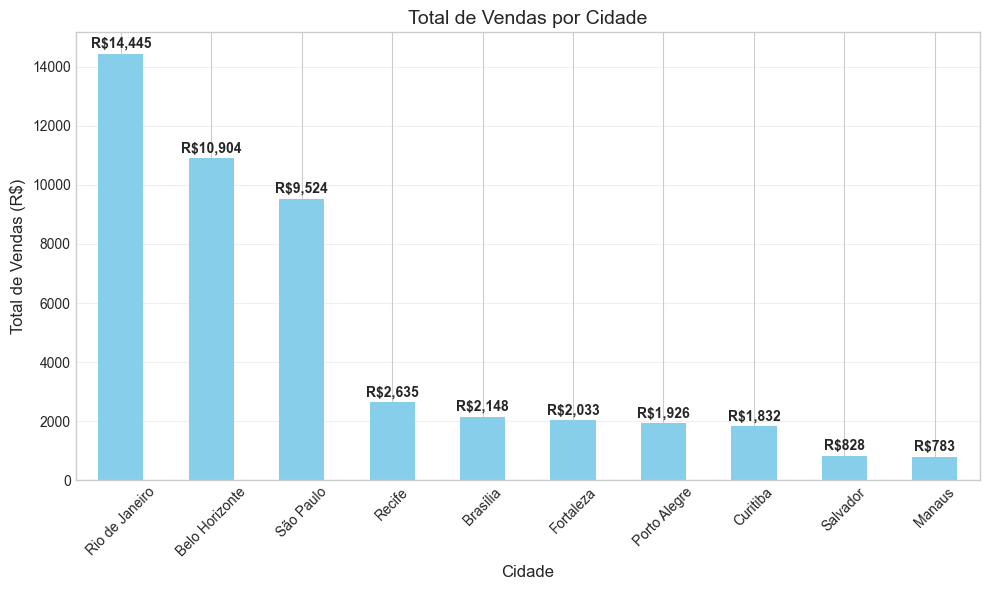

In [11]:

# Criando um gráfico de barras
plt.figure(figsize=(10, 6))
vendas_por_cidade.plot(kind='bar', color='skyblue')
plt.title('Total de Vendas por Cidade', fontsize=14)
plt.xlabel('Cidade', fontsize=12)
plt.ylabel('Total de Vendas (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionando valores no topo das barras
for i, valor in enumerate(vendas_por_cidade):
    plt.text(i, valor + 200, f'R${valor:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Exercício 2: Análise de Vendas por Categoria de Produto

Identifique as categorias de produtos mais vendidas em termos de quantidade e valor total.

In [ ]:
# Agrupamento com múltiplas funções de agregação
dados = df.groupby('Categoria_Produto').agg({
    'Quantidade': ['sum'],
    'Valor_Total': ['sum']
})
dados




,Quantidade,Valor_Total
,sum,sum
Categoria_Produto,,
Alimentos,51,1548.6
Eletrônicos,27,32475.5
Móveis,14,10241.0
Roupas,25,2791.5


<Figure size 1000x500 with 0 Axes>

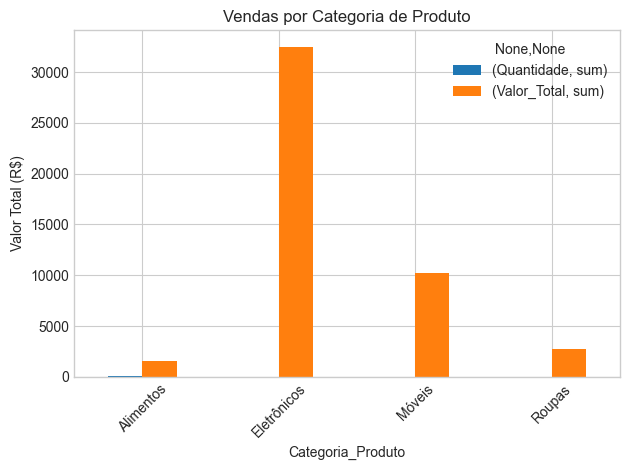

In [17]:
# Gráfico simples
plt.figure(figsize=(10, 5))
dados.plot(kind='bar')
plt.title('Vendas por Categoria de Produto')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Exercício 3: Análise Temporal de Vendas

Analise a tendência de vendas ao longo do tempo. Converta a coluna de data para o formato datetime, agrupe as vendas por mês e visualize a tendência.

In [22]:
df['Data'] = pd.to_datetime(df['Data'])

df['Mês'] = df['Data'].dt.strftime('%Y-%m')

# Agrupando as vendas por mês
vendas_mensais = df.groupby('Mês')['Valor_Total'].sum().reset_index()
vendas_mensais

,Mês,Valor_Total
0,2023-01,8602.5
1,2023-02,3588.0
2,2023-03,4092.0
3,2023-04,3630.0
4,2023-05,2598.0
5,2023-06,7344.0
6,2023-07,4355.0
7,2023-08,2884.5
8,2023-09,2735.6
9,2023-10,7227.0


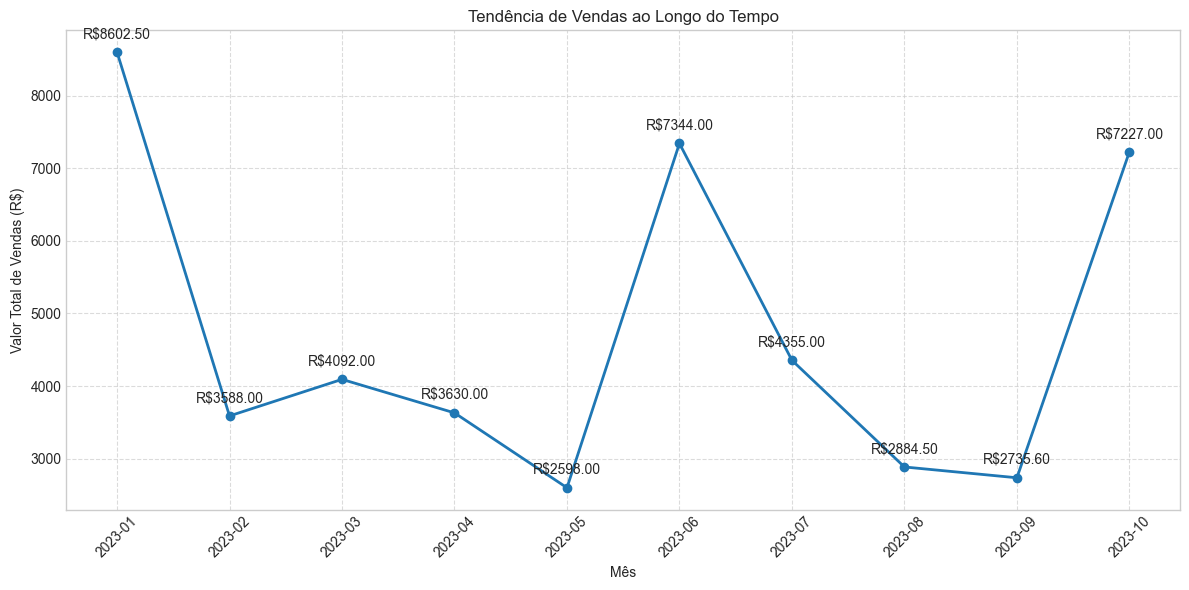

In [24]:
# Criando um gráfico de linha para visualizar a tendência
plt.figure(figsize=(12, 6))
plt.plot(vendas_mensais['Mês'], vendas_mensais['Valor_Total'], marker='o', linestyle='-', linewidth=2)
plt.title('Tendência de Vendas ao Longo do Tempo')
plt.xlabel('Mês')
plt.ylabel('Valor Total de Vendas (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Adicionando os valores nos pontos do gráfico
for i, valor in enumerate(vendas_mensais['Valor_Total']):
    plt.annotate(f'R${valor:.2f}', 
                 (vendas_mensais['Mês'][i], valor),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center')

plt.tight_layout()
plt.show()

## Exercício 4: Análise de Desempenho de Vendedores

Identifique os vendedores com melhor desempenho com base no total de vendas e no número de transações.

In [37]:
dados = df.groupby('Nome_Vendedor').agg({
    'Quantidade': ['sum'],
    'Valor_Total': ['sum']
})
# Sort the DataFrame by total value first
dados_ordenados = dados.sort_values(by=[('Valor_Total', 'sum')], ascending=False)
dados_ordenados

,Quantidade,Valor_Total
,sum,sum
Nome_Vendedor,,
Bruno Costa,9,14445.0
Carla Souza,18,10904.0
Ana Oliveira,12,9523.5
Igor Silva,4,2635.0
Daniel Lima,26,2147.5
Helena Costa,4,2033.0
Gabriel Alves,9,1926.0
Eduardo Santos,10,1832.0


## Exercício 5: Segmentação de Clientes

Segmente os clientes com base no valor total de compras e frequência de compras. Crie categorias como 'Alto Valor', 'Médio Valor' e 'Baixo Valor'.

In [40]:
cliente_segmentacao = df.groupby('Nome_Cliente').agg({
    'Valor_Total': 'sum',
    'Frequencia_Compra': 'mean'
}).reset_index()

# Definindo os limites para segmentação por valor
valor_limites = [
    cliente_segmentacao['Valor_Total'].quantile(0.33),
    cliente_segmentacao['Valor_Total'].quantile(0.67)
]

# Definindo os limites para segmentação por frequência
freq_limites = [
    cliente_segmentacao['Frequencia_Compra'].quantile(0.33),
    cliente_segmentacao['Frequencia_Compra'].quantile(0.67)
]

# Criando as categorias de valor
def categorizar_valor(valor):
    if valor <= valor_limites[0]:
        return 'Baixo Valor'
    elif valor <= valor_limites[1]:
        return 'Médio Valor'
    else:
        return 'Alto Valor'

# Criando as categorias de frequência
def categorizar_frequencia(freq):
    if freq <= freq_limites[0]:
        return 'Baixa Frequência'
    elif freq <= freq_limites[1]:
        return 'Média Frequência'
    else:
        return 'Alta Frequência'

In [44]:
# Exercício 5: Segmentação de Clientes

# Agrupando os dados por cliente para calcular o valor total de compras e a média de frequência
cliente_segmentacao = df.groupby('Nome_Cliente').agg({
    'Valor_Total': 'sum',
    'Frequencia_Compra': 'mean'
}).reset_index()

# Definindo os limites para segmentação por valor
valor_limites = [
    cliente_segmentacao['Valor_Total'].quantile(0.33),
    cliente_segmentacao['Valor_Total'].quantile(0.67)
]

# Definindo os limites para segmentação por frequência
freq_limites = [
    cliente_segmentacao['Frequencia_Compra'].quantile(0.33),
    cliente_segmentacao['Frequencia_Compra'].quantile(0.67)
]

# Criando as categorias de valor
def categorizar_valor(valor):
    if valor <= valor_limites[0]:
        return 'Baixo Valor'
    elif valor <= valor_limites[1]:
        return 'Médio Valor'
    else:
        return 'Alto Valor'

# Criando as categorias de frequência
def categorizar_frequencia(freq):
    if freq <= freq_limites[0]:
        return 'Baixa Frequência'
    elif freq <= freq_limites[1]:
        return 'Média Frequência'
    else:
        return 'Alta Frequência'

# Aplicando as funções para criar as categorias
cliente_segmentacao['Categoria_Valor'] = cliente_segmentacao['Valor_Total'].apply(categorizar_valor)
cliente_segmentacao['Categoria_Frequencia'] = cliente_segmentacao['Frequencia_Compra'].apply(categorizar_frequencia)

# Criando uma categoria combinada
cliente_segmentacao['Segmento'] = cliente_segmentacao['Categoria_Valor'] + ' / ' + cliente_segmentacao['Categoria_Frequencia']

# Exibindo o resultado
print("Segmentação de Clientes:")
print(cliente_segmentacao[['Nome_Cliente', 'Valor_Total', 'Frequencia_Compra', 'Categoria_Valor', 'Categoria_Frequencia', 'Segmento']])

# Contando o número de clientes em cada segmento
print("\nDistribuição de clientes por categoria de valor:")
print(cliente_segmentacao['Categoria_Valor'].value_counts())

print("\nDistribuição de clientes por categoria de frequência:")
print(cliente_segmentacao['Categoria_Frequencia'].value_counts())


Segmentação de Clientes:
         Nome_Cliente  Valor_Total  Frequencia_Compra Categoria_Valor Categoria_Frequencia                        Segmento
0      Aline Ferreira       1600.0                2.0      Alto Valor     Média Frequência   Alto Valor / Média Frequência
1        Amanda Gomes        114.0                3.0     Baixo Valor      Alta Frequência   Baixo Valor / Alta Frequência
2         Ana Pereira        212.5                4.0     Baixo Valor      Alta Frequência   Baixo Valor / Alta Frequência
3      André Oliveira        340.0                2.0     Médio Valor     Média Frequência  Médio Valor / Média Frequência
4       Beatriz Alves        180.0                2.0     Baixo Valor     Média Frequência  Baixo Valor / Média Frequência
5         Bianca Lima       2125.0                1.0      Alto Valor     Baixa Frequência   Alto Valor / Baixa Frequência
6    Camila Rodrigues       1530.0                1.0      Alto Valor     Baixa Frequência   Alto Valor / Baixa Fr

## Exercício 6: Análise de Correlação

Investigue a correlação entre diferentes variáveis numéricas no dataset, como preço, quantidade, desconto e vendas totais.

In [45]:
# Exercício 6: Análise de Correlação

# Selecionando apenas as variáveis numéricas para análise
variaveis_numericas = df.select_dtypes(include=['int64', 'float64'])

# Calculando a matriz de correlação
matriz_correlacao = variaveis_numericas.corr()

# Exibindo a matriz de correlação
print("Matriz de Correlação:")
print(matriz_correlacao)


Matriz de Correlação:
                   Quantidade  Preco_Unitario  Desconto  Valor_Total     Custo     Lucro  Frequencia_Compra
Quantidade           1.000000       -0.485985 -0.192393    -0.464755 -0.454490 -0.484222           0.738464
Preco_Unitario      -0.485985        1.000000  0.311042     0.971978  0.978244  0.868665          -0.332760
Desconto            -0.192393        0.311042  1.000000     0.228552  0.250097  0.100026          -0.252197
Valor_Total         -0.464755        0.971978  0.228552     1.000000  0.997792  0.938651          -0.275570
Custo               -0.454490        0.978244  0.250097     0.997792  1.000000  0.913676          -0.269038
Lucro               -0.484222        0.868665  0.100026     0.938651  0.913676  1.000000          -0.289425
Frequencia_Compra    0.738464       -0.332760 -0.252197    -0.275570 -0.269038 -0.289425           1.000000


In [ ]:

# Criando um mapa de calor (heatmap) para visualizar a correlação
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

# Análise de correlações específicas
print("\nCorrelações com Valor_Total:")
print(matriz_correlacao['Valor_Total'].sort_values(ascending=False))

# Gráficos de dispersão para visualizar relações importantes
plt.figure(figsize=(16, 12))

# Relação entre Preço Unitário e Valor Total
plt.subplot(2, 2, 1)
sns.scatterplot(x='Preco_Unitario', y='Valor_Total', data=df, hue='Categoria_Produto', size='Quantidade', sizes=(50, 200), alpha=0.7)
plt.title('Relação entre Preço Unitário e Valor Total')
plt.grid(True, alpha=0.3)

# Relação entre Quantidade e Valor Total
plt.subplot(2, 2, 2)
sns.scatterplot(x='Quantidade', y='Valor_Total', data=df, hue='Categoria_Produto', size='Preco_Unitario', sizes=(50, 200), alpha=0.7)
plt.title('Relação entre Quantidade e Valor Total')
plt.grid(True, alpha=0.3)

# Relação entre Desconto e Valor Total
plt.subplot(2, 2, 3)
sns.scatterplot(x='Desconto', y='Valor_Total', data=df, hue='Categoria_Produto', size='Preco_Unitario', sizes=(50, 200), alpha=0.7)
plt.title('Relação entre Desconto e Valor Total')
plt.grid(True, alpha=0.3)

# Relação entre Custo e Lucro
plt.subplot(2, 2, 4)
sns.scatterplot(x='Custo', y='Lucro', data=df, hue='Categoria_Produto', size='Valor_Total', sizes=(50, 200), alpha=0.7)
plt.title('Relação entre Custo e Lucro')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise de correlação parcial (controlando para outras variáveis)
from scipy.stats import pearsonr

# Exemplo: Correlação entre Preço Unitário e Valor Total, controlando para Quantidade
print("\nAnálise de correlações específicas:")

# Correlação entre Preço Unitário e Valor Total
corr_preco_valor, p_value = pearsonr(df['Preco_Unitario'], df['Valor_Total'])
print(f"Correlação entre Preço Unitário e Valor Total: {corr_preco_valor:.3f} (p-value: {p_value:.3f})")

# Correlação entre Quantidade e Valor Total
corr_qtd_valor, p_value = pearsonr(df['Quantidade'], df['Valor_Total'])
print(f"Correlação entre Quantidade e Valor Total: {corr_qtd_valor:.3f} (p-value: {p_value:.3f})")

# Correlação entre Desconto e Valor Total
corr_desc_valor, p_value = pearsonr(df['Desconto'], df['Valor_Total'])
print(f"Correlação entre Desconto e Valor Total: {corr_desc_valor:.3f} (p-value: {p_value:.3f})")

# Correlação entre Custo e Lucro
corr_custo_lucro, p_value = pearsonr(df['Custo'], df['Lucro'])
print(f"Correlação entre Custo e Lucro: {corr_custo_lucro:.3f} (p-value: {p_value:.3f})")

## Exercício 7: Análise de Rentabilidade

Calcule a margem de lucro para cada transação e analise quais produtos, categorias ou regiões são mais rentáveis.

Dados com margem de lucro calculada:
        Produto Categoria_Produto          Cidade Estado  Valor_Total  Lucro  Margem_Lucro
0    Smartphone       Eletrônicos       São Paulo     SP       2280.0  480.0         21.05
1          Sofá            Móveis  Rio de Janeiro     RJ       2250.0  450.0         20.00
2      Notebook       Eletrônicos  Belo Horizonte     MG       3500.0  700.0         20.00
3      Camiseta            Roupas        Brasília     DF        212.5   87.5         41.18
4  Cesta Básica         Alimentos       São Paulo     SP        360.0   80.0         22.22

Rentabilidade por Produto:
                Valor_Total   Lucro  Margem_Lucro
Produto                                          
Chocolate             156.0    68.0     43.685000
Camiseta              212.5    87.5     41.180000
Vestido               522.0   212.0     40.205000
Café                  284.6   113.6     39.925000
Calça                 998.0   388.0     38.880000
Cerveja               114.0    44.0    

C:\Users\wesley.neves\AppData\Local\Temp\ipykernel_10980\4016874333.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Margem_Lucro', y=margem_por_categoria.index, data=margem_por_categoria.reset_index(), palette='viridis')


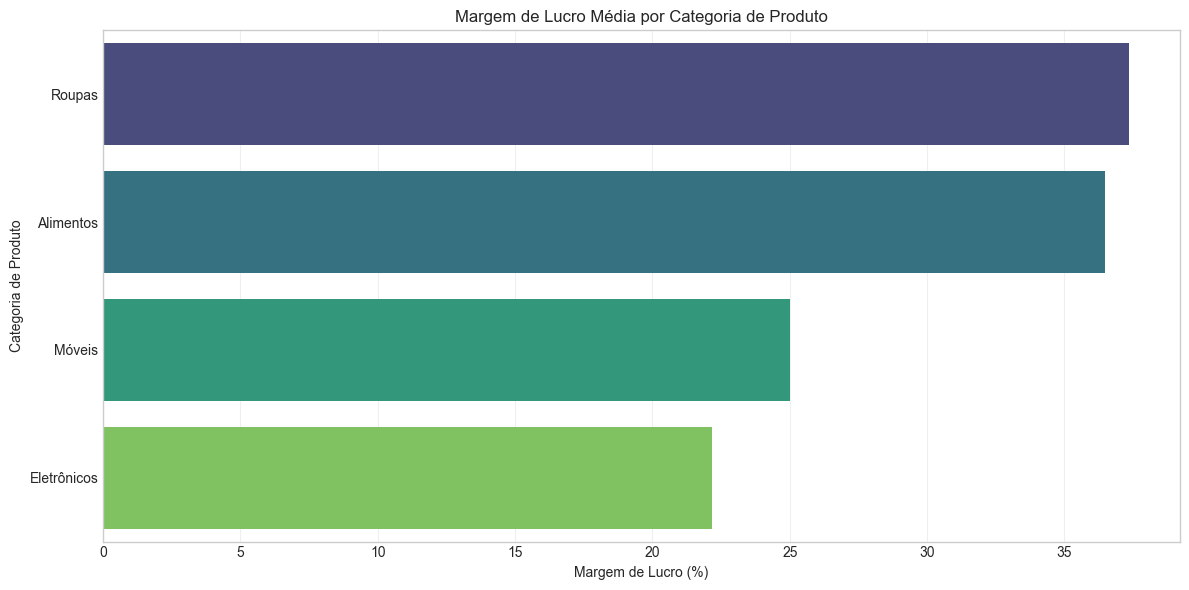

C:\Users\wesley.neves\AppData\Local\Temp\ipykernel_10980\4016874333.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Margem_Lucro', y=top_produtos.index, data=top_produtos.reset_index(), palette='viridis')


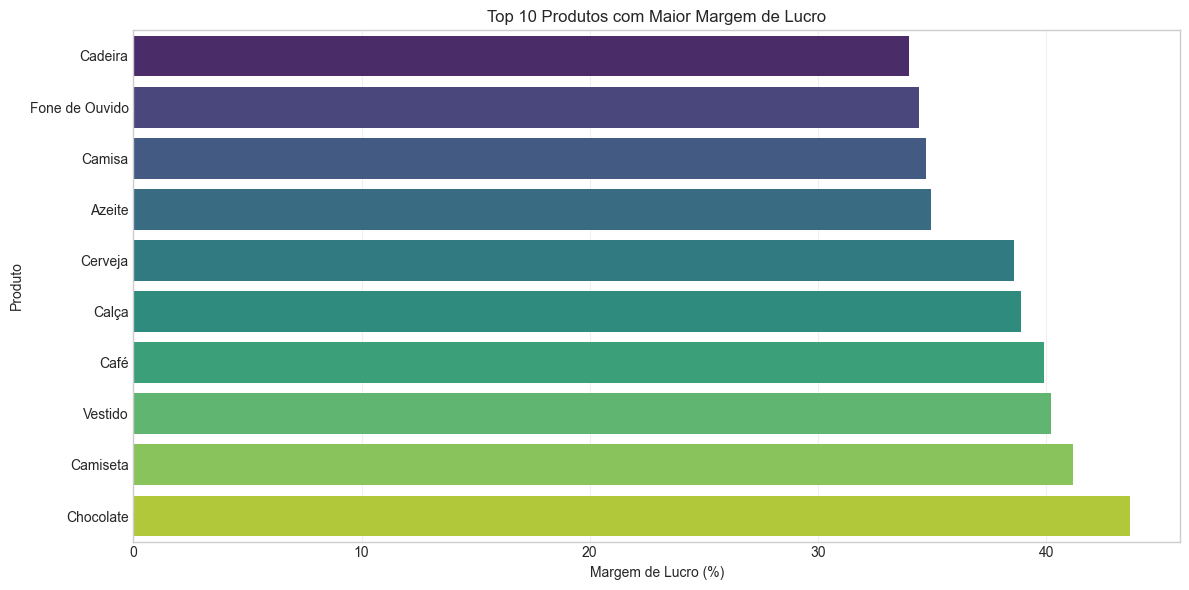

In [ ]:
# Exercício 7: Análise de Rentabilidade

# Calculando a margem de lucro para cada transação
df['Margem_Lucro'] = (df['Lucro'] / df['Valor_Total'] * 100).round(2)

# Exibindo as primeiras linhas com a nova coluna
print("Dados com margem de lucro calculada:")
print(df[['Produto', 'Categoria_Produto', 'Cidade', 'Estado', 'Valor_Total', 'Lucro', 'Margem_Lucro']].head())

# Análise por Produto
margem_por_produto = df.groupby('Produto').agg({
    'Valor_Total': 'sum',
    'Lucro': 'sum',
    'Margem_Lucro': 'mean'
}).sort_values(by='Margem_Lucro', ascending=False)

print("\nRentabilidade por Produto:")
print(margem_por_produto)

# Análise por Categoria
margem_por_categoria = df.groupby('Categoria_Produto').agg({
    'Valor_Total': 'sum',
    'Lucro': 'sum',
    'Margem_Lucro': 'mean'
}).sort_values(by='Margem_Lucro', ascending=False)

print("\nRentabilidade por Categoria:")
print(margem_por_categoria)

# Análise por Região (Estado)
margem_por_estado = df.groupby('Estado').agg({
    'Valor_Total': 'sum',
    'Lucro': 'sum',
    'Margem_Lucro': 'mean'
}).sort_values(by='Margem_Lucro', ascending=False)

print("\nRentabilidade por Estado:")
print(margem_por_estado)

# Análise por Cidade
margem_por_cidade = df.groupby('Cidade').agg({
    'Valor_Total': 'sum',
    'Lucro': 'sum',
    'Margem_Lucro': 'mean'
}).sort_values(by='Margem_Lucro', ascending=False)

print("\nRentabilidade por Cidade:")
print(margem_por_cidade.head(10))  # Mostrando apenas as 10 cidades mais rentáveis

# Visualizações
plt.figure(figsize=(12, 6))
sns.barplot(x='Margem_Lucro', y=margem_por_categoria.index, data=margem_por_categoria.reset_index(), palette='viridis')
plt.title('Margem de Lucro Média por Categoria de Produto')
plt.xlabel('Margem de Lucro (%)')
plt.ylabel('Categoria de Produto')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Top 10 produtos mais rentáveis
top_produtos = margem_por_produto.head(10).sort_values(by='Margem_Lucro')
plt.figure(figsize=(12, 6))
sns.barplot(x='Margem_Lucro', y=top_produtos.index, data=top_produtos.reset_index(), palette='viridis')
plt.title('Top 10 Produtos com Maior Margem de Lucro')
plt.xlabel('Margem de Lucro (%)')
plt.ylabel('Produto')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Exercício 8: Análise de Descontos

Investigue o impacto dos descontos nas vendas. Existe uma correlação entre o percentual de desconto e o volume de vendas?

In [48]:
# Exercício 8: Análise de Descontos

# Convertendo o desconto para percentual para melhor visualização
df['Desconto_Percentual'] = df['Desconto'] * 100

# Verificando a distribuição dos descontos
print("Estatísticas dos descontos:")
print(df['Desconto_Percentual'].describe())

# Agrupando por faixas de desconto para analisar o volume de vendas
faixas_desconto = [0, 5, 10, 15, 20, 100]
labels_faixas = ['0-5%', '5-10%', '10-15%', '15-20%', '20%+']

df['Faixa_Desconto'] = pd.cut(df['Desconto_Percentual'], bins=faixas_desconto, labels=labels_faixas, right=False)

# Análise por faixa de desconto
analise_desconto = df.groupby('Faixa_Desconto').agg({
    'Valor_Total': 'sum',
    'Quantidade': 'sum',
    'ID_Cliente': 'count'  # Número de transações
}).rename(columns={'ID_Cliente': 'Num_Transacoes'})


Estatísticas dos descontos:
count    50.000000
mean      5.600000
std       5.115004
min       0.000000
25%       0.000000
50%       5.000000
75%      10.000000
max      15.000000
Name: Desconto_Percentual, dtype: float64


C:\Users\wesley.neves\AppData\Local\Temp\ipykernel_10980\3992647998.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_desconto = df.groupby('Faixa_Desconto').agg({



Análise por faixa de desconto:
                Valor_Total  Quantidade  Num_Transacoes  Valor_Medio_Transacao  Quantidade_Media
Faixa_Desconto                                                                                  
0-5%                11279.0          45              17             663.470588          2.647059
5-10%               16490.1          45              16            1030.631250          2.812500
10-15%              11034.0          16              11            1003.090909          1.454545
15-20%               8253.5          11               6            1375.583333          1.833333
20%+                    0.0           0               0                    NaN               NaN


C:\Users\wesley.neves\AppData\Local\Temp\ipykernel_10980\1299263122.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_desconto.index, y='Valor_Total', data=analise_desconto, palette='viridis')


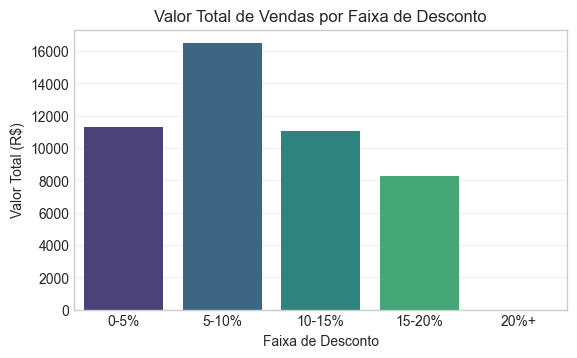

In [49]:

# Calculando o valor médio por transação para cada faixa de desconto
analise_desconto['Valor_Medio_Transacao'] = analise_desconto['Valor_Total'] / analise_desconto['Num_Transacoes']
analise_desconto['Quantidade_Media'] = analise_desconto['Quantidade'] / analise_desconto['Num_Transacoes']

print("\nAnálise por faixa de desconto:")
print(analise_desconto)

# Visualizando o impacto do desconto no volume de vendas
plt.figure(figsize=(14, 8))

# Gráfico 1: Valor total de vendas por faixa de desconto
plt.subplot(2, 2, 1)
sns.barplot(x=analise_desconto.index, y='Valor_Total', data=analise_desconto, palette='viridis')
plt.title('Valor Total de Vendas por Faixa de Desconto')
plt.xlabel('Faixa de Desconto')
plt.ylabel('Valor Total (R$)')
plt.grid(True, axis='y', alpha=0.3)


## Exercício 9: Análise de Vendas por Método de Envio

Compare as vendas e a lucratividade entre diferentes métodos de envio. Existe algum método que se destaca em termos de volume ou rentabilidade?

Métodos de envio disponíveis:
['Expresso' 'Padrão' 'Econômico']

Análise por método de envio:
              Valor_Total  Quantidade   Lucro  Num_Transacoes  Valor_Medio_Transacao  Lucro_Medio_Transacao  Margem_Lucro
Metodo_Envio                                                                                                             
Econômico          9601.5          29  2501.5              13             738.576923             192.423077         26.05
Expresso          25507.5          22  4667.5              17            1500.441176             274.558824         18.30
Padrão            11947.6          66  2963.6              20             597.380000             148.180000         24.80


C:\Users\wesley.neves\AppData\Local\Temp\ipykernel_10980\1438215019.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_envio.index, y='Valor_Total', data=analise_envio, palette='viridis')


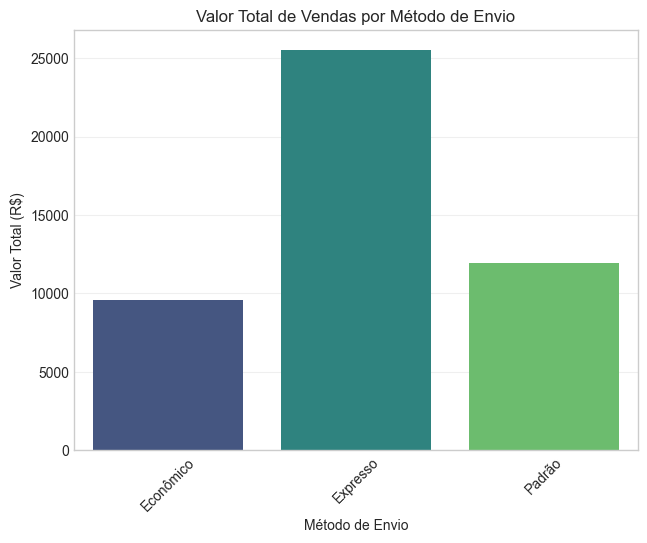

In [51]:
# Exercício 9: Análise de Vendas por Método de Envio

# Verificando os métodos de envio disponíveis
print("Métodos de envio disponíveis:")
print(df['Metodo_Envio'].unique())

# Análise básica por método de envio
analise_envio = df.groupby('Metodo_Envio').agg({
    'Valor_Total': 'sum',
    'Quantidade': 'sum',
    'Lucro': 'sum',
    'ID_Cliente': 'count'  # Número de transações
}).rename(columns={'ID_Cliente': 'Num_Transacoes'})

# Calculando métricas adicionais
analise_envio['Valor_Medio_Transacao'] = analise_envio['Valor_Total'] / analise_envio['Num_Transacoes']
analise_envio['Lucro_Medio_Transacao'] = analise_envio['Lucro'] / analise_envio['Num_Transacoes']
analise_envio['Margem_Lucro'] = (analise_envio['Lucro'] / analise_envio['Valor_Total'] * 100).round(2)

print("\nAnálise por método de envio:")
print(analise_envio)

# Visualizações
plt.figure(figsize=(16, 12))

# Gráfico 1: Valor total de vendas por método de envio
plt.subplot(2, 2, 1)
sns.barplot(x=analise_envio.index, y='Valor_Total', data=analise_envio, palette='viridis')
plt.title('Valor Total de Vendas por Método de Envio')
plt.xlabel('Método de Envio')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)


## Exercicio 10 ) Previsão de Vendas

C:\Users\wesley.neves\AppData\Local\Temp\ipykernel_10980\76706948.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vendas_mensais = df.groupby(pd.Grouper(key='Data', freq='M'))['Valor_Total'].sum().reset_index()


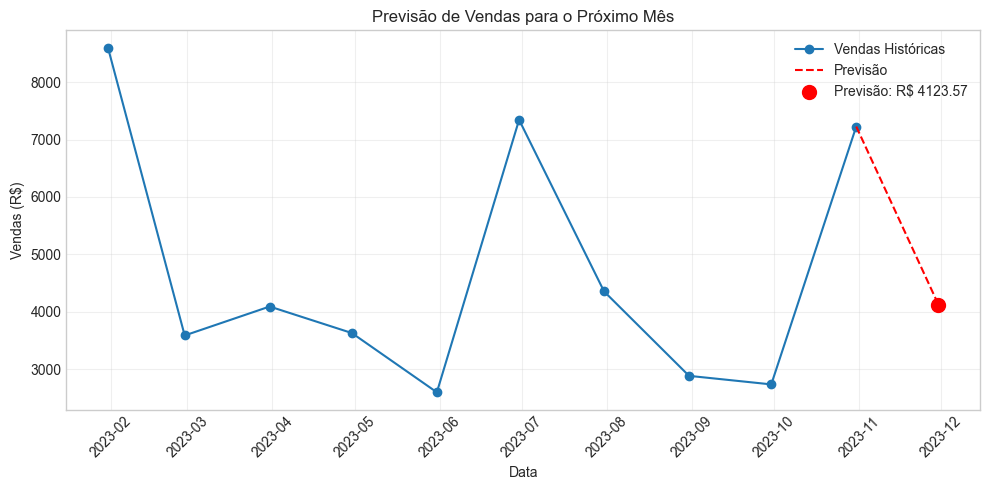

Previsão de vendas para November 2023: R$ 4123.57


In [55]:
# Modelo de Previsão de Vendas para o Próximo Mês

# Convertendo a coluna 'Data' para o formato datetime
df['Data'] = pd.to_datetime(df['Data'])

# Agrupando as vendas por mês
vendas_mensais = df.groupby(pd.Grouper(key='Data', freq='M'))['Valor_Total'].sum().reset_index()

# Criando uma feature numérica para representar o tempo
vendas_mensais['Tempo'] = range(len(vendas_mensais))

# Preparando os dados para o modelo
X = vendas_mensais[['Tempo']]
y = vendas_mensais['Valor_Total']

# Criando e treinando o modelo de regressão linear
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X, y)

# Fazendo previsão para o próximo mês
ultimo_mes = vendas_mensais['Tempo'].max()
proximo_mes = pd.DataFrame({'Tempo': [ultimo_mes + 1]})
previsao = modelo.predict(proximo_mes)[0]

# Criando data para o próximo mês
ultima_data = vendas_mensais['Data'].max()
proxima_data = ultima_data + pd.DateOffset(months=1)

# Visualizando os resultados
plt.figure(figsize=(10, 5))
plt.plot(vendas_mensais['Data'], vendas_mensais['Valor_Total'], 'o-', label='Vendas Históricas')
plt.plot([ultima_data, proxima_data], [vendas_mensais['Valor_Total'].iloc[-1], previsao], 'r--', label='Previsão')
plt.scatter(proxima_data, previsao, color='red', s=100, label=f'Previsão: R$ {previsao:.2f}')
plt.title('Previsão de Vendas para o Próximo Mês')
plt.xlabel('Data')
plt.ylabel('Vendas (R$)')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Exibindo o resultado da previsão
print(f"Previsão de vendas para {proxima_data.strftime('%B %Y')}: R$ {previsao:.2f}")

